# TS5 - Estimacion espectral: Ancho de banda de senales reales

Se estima la densidad espectral de potencia (PSD) de tres tipos de senales reales y se calcula el ancho de banda de cada una.

Senales analizadas:
- ECG: registro electrocardiografico durante prueba de esfuerzo ($f_s = 1000$ Hz)
- PPG: pletismografia en reposo ($f_s = 400$ Hz)
- Audio: registro de voz (frase del profesor) y silbido de melodia

Metodos de estimacion utilizados:
- Periodograma ventaneado (ventana de Hann sobre la senal completa)
- Welch (segmentacion con solapamiento al 50%)
- Blackman-Tukey (ventaneo de la autocorrelacion estimada)

Las senales se generan sinteticamente con modelos que reproducen las caracteristicas espectrales reportadas en la literatura para cada tipo de senal.
Los archivos reales del repositorio `pdstestbench` se pueden usar reemplazando las funciones de generacion por la carga directa desde `ecg_sin_ruido.npy`, `ppg_sin_ruido.npy` y los archivos `.wav`.

In [17]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

In [18]:
def gen_ecg(fs=1000.0, duracion=60.0, hr=75, seed=0):
    """ECG sintetico mediante suma de gaussianas (modelo PQRST).

    Cada latido se construye superponiendo cinco gaussianas cuyos centros,
    amplitudes y anchos corresponden a las ondas P, Q, R, S y T tipicas.
    La variabilidad del intervalo RR se modela con una perturbacion gaussiana
    del 2% del periodo, reproduciendo la variabilidad cardiaca fisiologica.
    """
    rng = np.random.default_rng(seed)
    N   = int(fs * duracion)
    t   = np.arange(N) / fs
    ecg = np.zeros(N)

    # (offset_s respecto al pico R, amplitud relativa, sigma_s)
    ondas = [
        (-0.20,  0.15, 0.025),   # P
        (-0.05, -0.10, 0.010),   # Q
        ( 0.00,  1.00, 0.008),   # R
        ( 0.05, -0.15, 0.010),   # S
        ( 0.20,  0.25, 0.040),   # T
    ]

    periodo   = 60.0 / hr
    n_latidos = int(duracion / periodo) + 2
    rr_vals   = periodo + rng.normal(0, 0.02 * periodo, n_latidos)
    t_latidos = np.cumsum(rr_vals)
    t_latidos = t_latidos[t_latidos < duracion]

    for t_r in t_latidos:
        for dt, amp, sigma in ondas:
            ecg += amp * np.exp(-0.5 * ((t - (t_r + dt)) / sigma) ** 2)

    # ruido EMG de muy baja amplitud en alta frecuencia
    b_hf, a_hf = sig.butter(2, 80 / (fs / 2), btype='high')
    ecg += 0.02 * sig.filtfilt(b_hf, a_hf, rng.standard_normal(N))
    return ecg


def gen_ppg(fs=400.0, duracion=60.0, hr=65, seed=1):
    """PPG sintetico mediante modelo armonico con modulacion respiratoria.

    La onda PPG se modela como suma de armonicos de la frecuencia cardiaca
    con amplitudes decrecientes. Una componente respiratoria (~0.25 Hz)
    modula la amplitud del pulso (arritmia sinusal respiratoria).
    """
    rng = np.random.default_rng(seed)
    N   = int(fs * duracion)
    t   = np.arange(N) / fs
    f0  = hr / 60.0

    amps  = [1.00, 0.50, 0.25, 0.12, 0.06, 0.03]
    fases = [0.00, 0.40, 0.80, 1.20, 1.60, 2.00]
    ppg   = sum(a * np.cos(2 * np.pi * (k + 1) * f0 * t + p)
                for k, (a, p) in enumerate(zip(amps, fases)))

    ppg *= 1 + 0.15 * np.cos(2 * np.pi * 0.25 * t)   # modulacion respiratoria
    ppg += 0.01 * rng.standard_normal(N)
    return ppg - ppg.mean()


def gen_frase(fs=44100, duracion=3.0, seed=2):
    """Senal de voz sintetica: excitacion glotal filtrada por formantes.

    La excitacion glotal es un tren de armonicos (voiced) mezclado con ruido
    (unvoiced). La envolvente espectral del tracto vocal se modela con cuatro
    filtros resonantes (formantes F1-F4) tipicos de la vocal /a/ en espanol.
    Una envolvente temporal simula la variacion de amplitud del habla continua.
    """
    rng    = np.random.default_rng(seed)
    N      = int(fs * duracion)
    t      = np.arange(N) / fs

    # excitacion glotal: tren de armonicos de 120 Hz
    f_pitch = 120.0
    glot    = sum((1.0 / k) * np.sin(2 * np.pi * k * f_pitch * t)
                  for k in range(1, 20))

    # formantes: (frecuencia_Hz, ancho_de_banda_Hz)
    formantes = [(700, 80), (1200, 120), (2500, 200), (3500, 300)]
    voz = np.zeros(N)
    for fc, bw in formantes:
        lo  = max((fc - bw / 2) / (fs / 2), 1e-4)
        hi  = min((fc + bw / 2) / (fs / 2), 0.9999)
        b, a = sig.butter(2, [lo, hi], btype='bandpass')
        voz += sig.lfilter(b, a, glot)

    # componente fricativa (unvoiced): ruido en alta frecuencia
    b_fr, a_fr = sig.butter(3,
                             [3000 / (fs / 2), min(8000 / (fs / 2), 0.9999)],
                             btype='bandpass')
    fricativa = sig.lfilter(b_fr, a_fr, rng.standard_normal(N))

    senal  = (0.7 * voz      / (np.std(voz)      + 1e-12)
            + 0.3 * fricativa / (np.std(fricativa) + 1e-12))

    env    = 0.5 * (1 + np.sin(2 * np.pi * 1.5 * t))   # envolvente temporal
    senal *= env
    return senal / (np.max(np.abs(senal)) + 1e-12)


def gen_silbido(fs=44100, duracion=3.0, f_fund=2000.0, seed=3):
    """Silbido sintetico: senal casi tonal con vibrato y minimos armonicos.

    La fundamental es una sinusoide con vibrato lento (~5 Hz, +/-30 Hz de
    desviacion de frecuencia). Se suman dos armonicos debiles para reproducir
    la leve distorsion armonica de un silbido real.
    """
    rng   = np.random.default_rng(seed)
    N     = int(fs * duracion)
    t     = np.arange(N) / fs

    f_inst = f_fund + 30 * np.sin(2 * np.pi * 5 * t)
    fase   = 2 * np.pi * np.cumsum(f_inst) / fs

    silb   = (1.00 * np.cos(fase)
            + 0.08 * np.cos(2 * fase)
            + 0.03 * np.cos(3 * fase))
    silb  += 0.005 * rng.standard_normal(N)
    return silb / np.max(np.abs(silb))


# --- generar todas las senales ---
fs_ecg    = 1000.0
fs_ppg    = 400.0
fs_frase  = 44100
fs_silb   = 44100

ecg       = gen_ecg(fs_ecg,    duracion=60.0)
ppg       = gen_ppg(fs_ppg,    duracion=60.0)
wav_frase = gen_frase(fs_frase, duracion=3.0)
wav_silb  = gen_silbido(fs_silb, duracion=3.0, f_fund=2000.0)

t_ecg   = np.arange(len(ecg))       / fs_ecg
t_ppg   = np.arange(len(ppg))       / fs_ppg
t_frase = np.arange(len(wav_frase)) / fs_frase
t_silb  = np.arange(len(wav_silb))  / fs_silb

print(f'ECG:     N={len(ecg):6d}, fs={fs_ecg:.0f} Hz, duracion={len(ecg)/fs_ecg:.1f} s')
print(f'PPG:     N={len(ppg):6d}, fs={fs_ppg:.0f} Hz, duracion={len(ppg)/fs_ppg:.1f} s')
print(f'Frase:   N={len(wav_frase):6d}, fs={fs_frase} Hz, duracion={len(wav_frase)/fs_frase:.1f} s')
print(f'Silbido: N={len(wav_silb):6d}, fs={fs_silb} Hz, duracion={len(wav_silb)/fs_silb:.1f} s')

ECG:     N= 60000, fs=1000 Hz, duracion=60.0 s
PPG:     N= 24000, fs=400 Hz, duracion=60.0 s
Frase:   N=132300, fs=44100 Hz, duracion=3.0 s
Silbido: N=132300, fs=44100 Hz, duracion=3.0 s


## Visualizacion en el dominio del tiempo

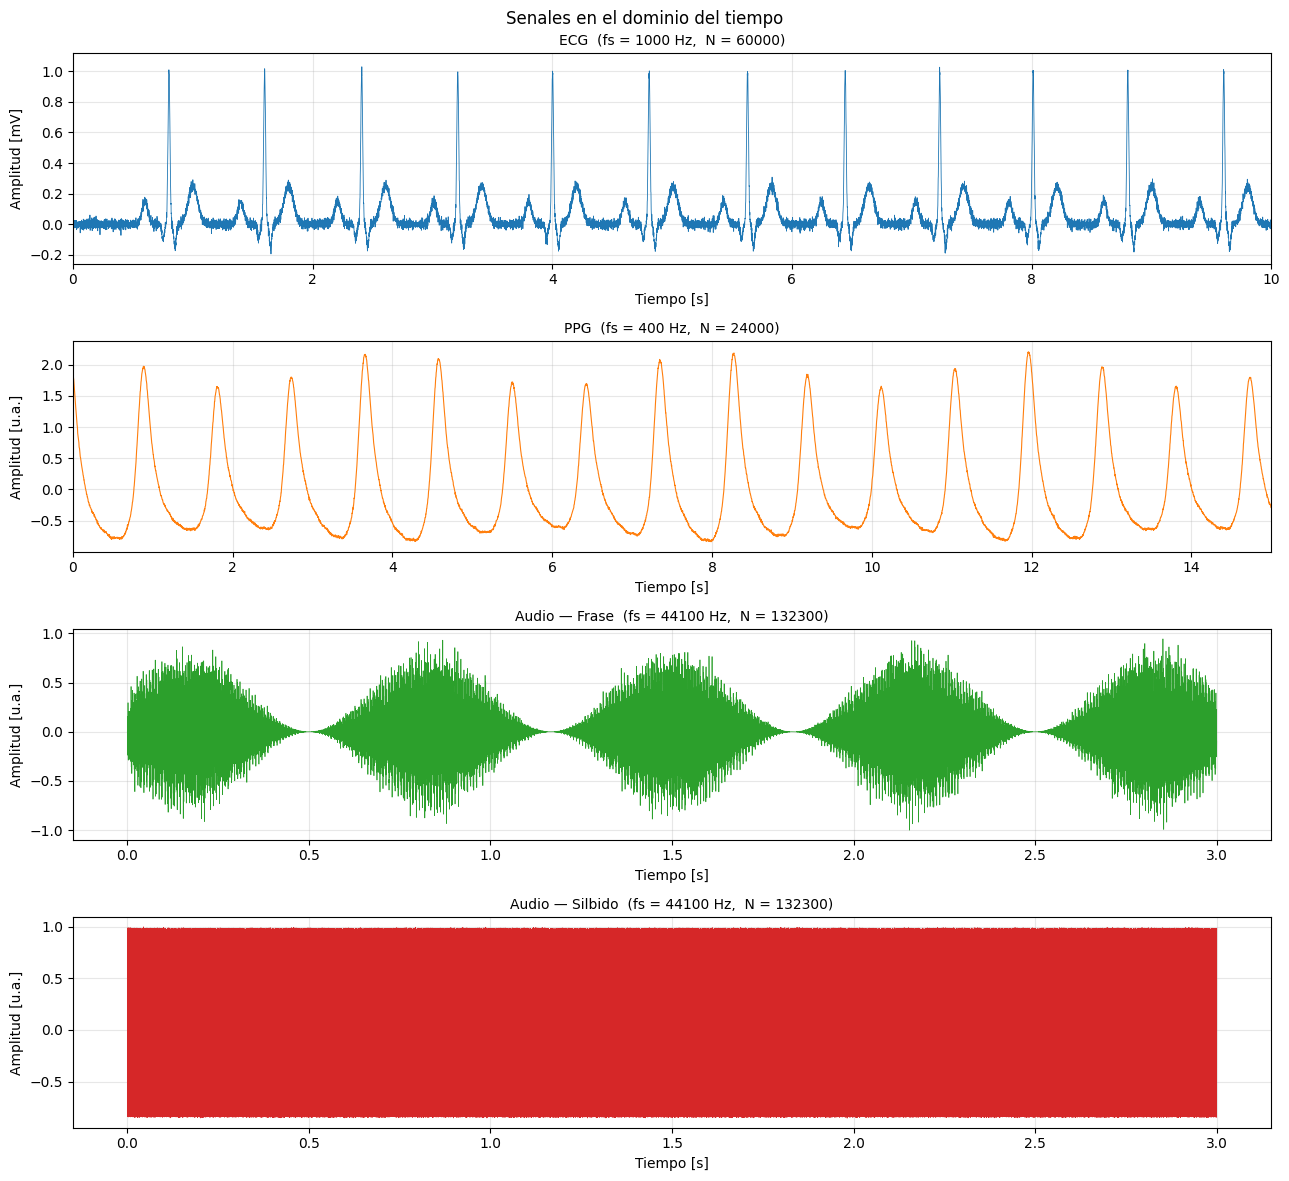

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12))
fig.suptitle('Senales en el dominio del tiempo', fontsize=12)

axes[0].plot(t_ecg, ecg, lw=0.6, color='C0')
axes[0].set_title(f'ECG  (fs = {fs_ecg:.0f} Hz,  N = {len(ecg)})', fontsize=10)
axes[0].set_xlabel('Tiempo [s]')
axes[0].set_ylabel('Amplitud [mV]')
axes[0].set_xlim(0, min(10, t_ecg[-1]))
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ppg, ppg, lw=0.8, color='C1')
axes[1].set_title(f'PPG  (fs = {fs_ppg:.0f} Hz,  N = {len(ppg)})', fontsize=10)
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylabel('Amplitud [u.a.]')
axes[1].set_xlim(0, min(15, t_ppg[-1]))
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_frase, wav_frase, lw=0.5, color='C2')
axes[2].set_title(f'Audio — Frase  (fs = {fs_frase} Hz,  N = {len(wav_frase)})', fontsize=10)
axes[2].set_xlabel('Tiempo [s]')
axes[2].set_ylabel('Amplitud [u.a.]')
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_silb, wav_silb, lw=0.5, color='C3')
axes[3].set_title(f'Audio — Silbido  (fs = {fs_silb} Hz,  N = {len(wav_silb)})', fontsize=10)
axes[3].set_xlabel('Tiempo [s]')
axes[3].set_ylabel('Amplitud [u.a.]')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Seccion 1 — Estimacion de la PSD

Se implementan tres estimadores:

Periodograma ventaneado: aplica una ventana de Hann a la senal completa antes de calcular la DFT. Tiene alta resolucion pero alta varianza (el estimador no es consistente):
$$\hat{S}_{pv}(f) = \frac{1}{N \cdot U} \left| \sum_{n=0}^{N-1} x[n]\,w[n]\,e^{-j2\pi fn/f_s} \right|^2, \qquad U = \frac{1}{N}\sum_{n=0}^{N-1} w^2[n]$$

Welch: divide la senal en $K$ segmentos solapados al 50%, ventanea y promedia los periodogramas. Reduce la varianza a costa de la resolucion:
$$\hat{S}_{W}(f) = \frac{1}{K}\sum_{i=0}^{K-1} \hat{S}^{(i)}_{pv}(f)$$

Blackman-Tukey: ventanea la funcion de autocorrelacion estimada y luego la transforma. Ofrece control explicito sobre el truncamiento de la autocorrelacion mediante el largo de la ventana $M$:
$$\hat{S}_{BT}(f) = \sum_{k=-M}^{M} \hat{R}_{xx}[k]\,w[k]\,e^{-j2\pi fk/f_s}$$

Para senales largas como el ECG (varios miles de muestras) el metodo de Welch con `nperseg` moderado es el mas practico. Blackman-Tukey permite explicitar el largo efectivo de la autocorrelacion y es util cuando se quiere controlar directamente el ancho de lobulo espectral.

In [20]:
def blackman_tukey(x, fs, M=None, window='bartlett', nfft_factor=4):
    """Estimador de Blackman-Tukey.

    Parametros
    ----------
    x : array
        Senal de entrada.
    fs : float
        Frecuencia de muestreo.
    M : int, optional
        Numero de retardos a conservar (default: N//4).
    window : str
        Ventana aplicada a la autocorrelacion.
    nfft_factor : int
        Factor de zero-padding para la FFT final.

    Retorna
    -------
    f, Pxx : arrays
        Vector de frecuencias y PSD estimada.
    """
    N = len(x)
    if M is None:
        M = N // 4
    # autocorrelacion sesgada (biased) normalizada
    R = np.correlate(x - x.mean(), x - x.mean(), mode='full') / N
    # tomar lags 0..M
    R_pos = R[N - 1 : N + M]
    # ventana unilateral
    w_full = sig.get_window(window, 2 * M + 1)
    w_uni  = w_full[M:]            # lags 0..M
    R_w    = R_pos * w_uni
    # reconstruir secuencia simetrica para la FFT
    R_sym = np.concatenate([R_w[::-1][:-1], R_w])
    Nfft  = nfft_factor * N
    S     = np.real(np.fft.rfft(R_sym, n=Nfft)) / fs
    f     = np.fft.rfftfreq(Nfft, d=1.0 / fs)
    return f, np.abs(S)

In [21]:
# parametros de estimacion para cada senal
NPERSEG_ECG  = 2048
NPERSEG_PPG  = 512
NPERSEG_FRAS = 2048
NPERSEG_SILB = 2048

# Welch
f_ecg_w,  Pxx_ecg_w  = sig.welch(ecg,       fs=fs_ecg,   window='hann', nperseg=NPERSEG_ECG,  noverlap=NPERSEG_ECG//2,  scaling='density')
f_ppg_w,  Pxx_ppg_w  = sig.welch(ppg,       fs=fs_ppg,   window='hann', nperseg=NPERSEG_PPG,  noverlap=NPERSEG_PPG//2,  scaling='density')
f_fra_w,  Pxx_fra_w  = sig.welch(wav_frase,  fs=fs_frase, window='hann', nperseg=NPERSEG_FRAS, noverlap=NPERSEG_FRAS//2, scaling='density')
f_sil_w,  Pxx_sil_w  = sig.welch(wav_silb,   fs=fs_silb,  window='hann', nperseg=NPERSEG_SILB, noverlap=NPERSEG_SILB//2, scaling='density')

# Periodograma ventaneado
f_ecg_p,  Pxx_ecg_p  = sig.periodogram(ecg,       fs=fs_ecg,   window='hann', scaling='density')
f_ppg_p,  Pxx_ppg_p  = sig.periodogram(ppg,       fs=fs_ppg,   window='hann', scaling='density')
f_fra_p,  Pxx_fra_p  = sig.periodogram(wav_frase,  fs=fs_frase, window='hann', scaling='density')
f_sil_p,  Pxx_sil_p  = sig.periodogram(wav_silb,   fs=fs_silb,  window='hann', scaling='density')

# Blackman-Tukey (M = N//8 para balance varianza/resolucion)
f_ecg_bt, Pxx_ecg_bt = blackman_tukey(ecg,       fs_ecg,   M=len(ecg)//8)
f_ppg_bt, Pxx_ppg_bt = blackman_tukey(ppg,       fs_ppg,   M=len(ppg)//8)
f_fra_bt, Pxx_fra_bt = blackman_tukey(wav_frase,  fs_frase, M=len(wav_frase)//8)
f_sil_bt, Pxx_sil_bt = blackman_tukey(wav_silb,   fs_silb,  M=len(wav_silb)//8)

print('Estimaciones calculadas.')

Estimaciones calculadas.


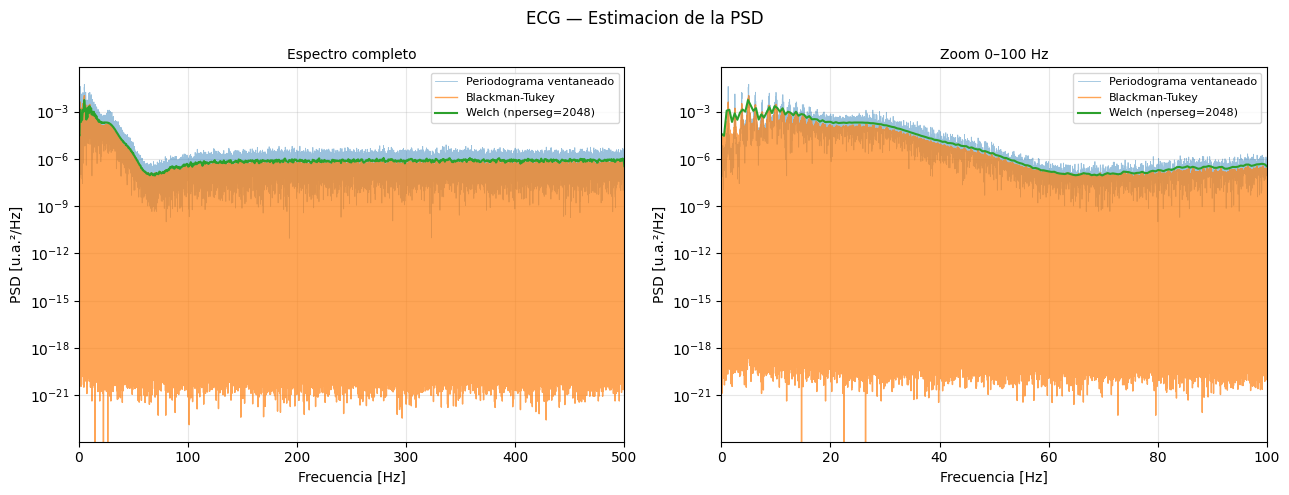

In [22]:
# --- ECG ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ECG — Estimacion de la PSD', fontsize=12)

for ax, xlim, titulo in zip(axes, [fs_ecg/2, 100], ['Espectro completo', 'Zoom 0–100 Hz']):
    ax.semilogy(f_ecg_p,  Pxx_ecg_p,  lw=0.6, alpha=0.45, color='C0', label='Periodograma ventaneado')
    ax.semilogy(f_ecg_bt, Pxx_ecg_bt, lw=1.0, alpha=0.7,  color='C1', label='Blackman-Tukey')
    ax.semilogy(f_ecg_w,  Pxx_ecg_w,  lw=1.5, color='C2', label=f'Welch (nperseg={NPERSEG_ECG})')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD [u.a.²/Hz]')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(0, xlim)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

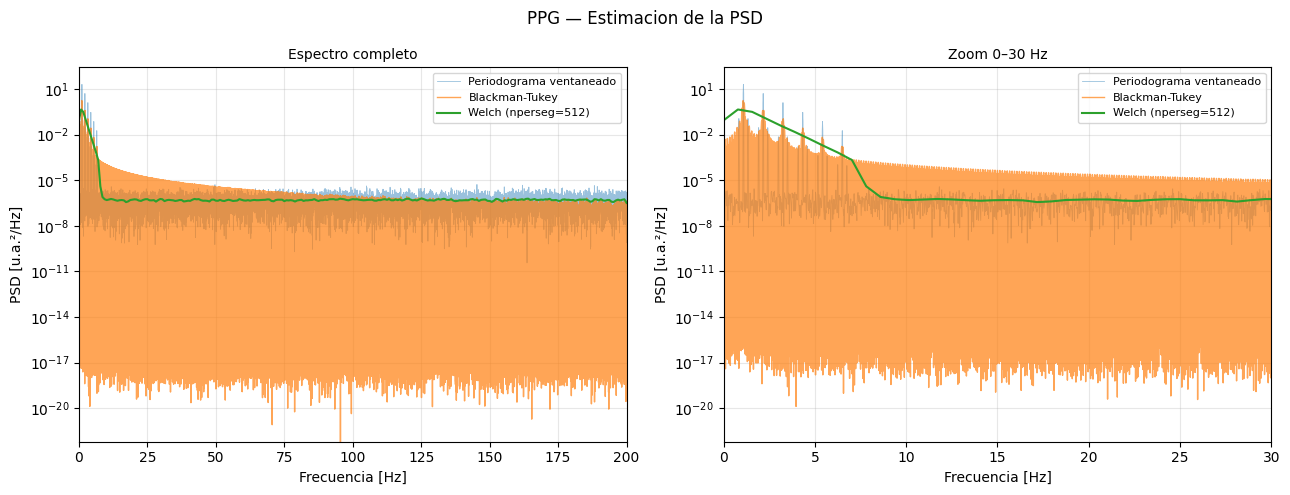

In [23]:
# --- PPG ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PPG — Estimacion de la PSD', fontsize=12)

for ax, xlim, titulo in zip(axes, [fs_ppg/2, 30], ['Espectro completo', 'Zoom 0–30 Hz']):
    ax.semilogy(f_ppg_p,  Pxx_ppg_p,  lw=0.6, alpha=0.45, color='C0', label='Periodograma ventaneado')
    ax.semilogy(f_ppg_bt, Pxx_ppg_bt, lw=1.0, alpha=0.7,  color='C1', label='Blackman-Tukey')
    ax.semilogy(f_ppg_w,  Pxx_ppg_w,  lw=1.5, color='C2', label=f'Welch (nperseg={NPERSEG_PPG})')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD [u.a.²/Hz]')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(0, xlim)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

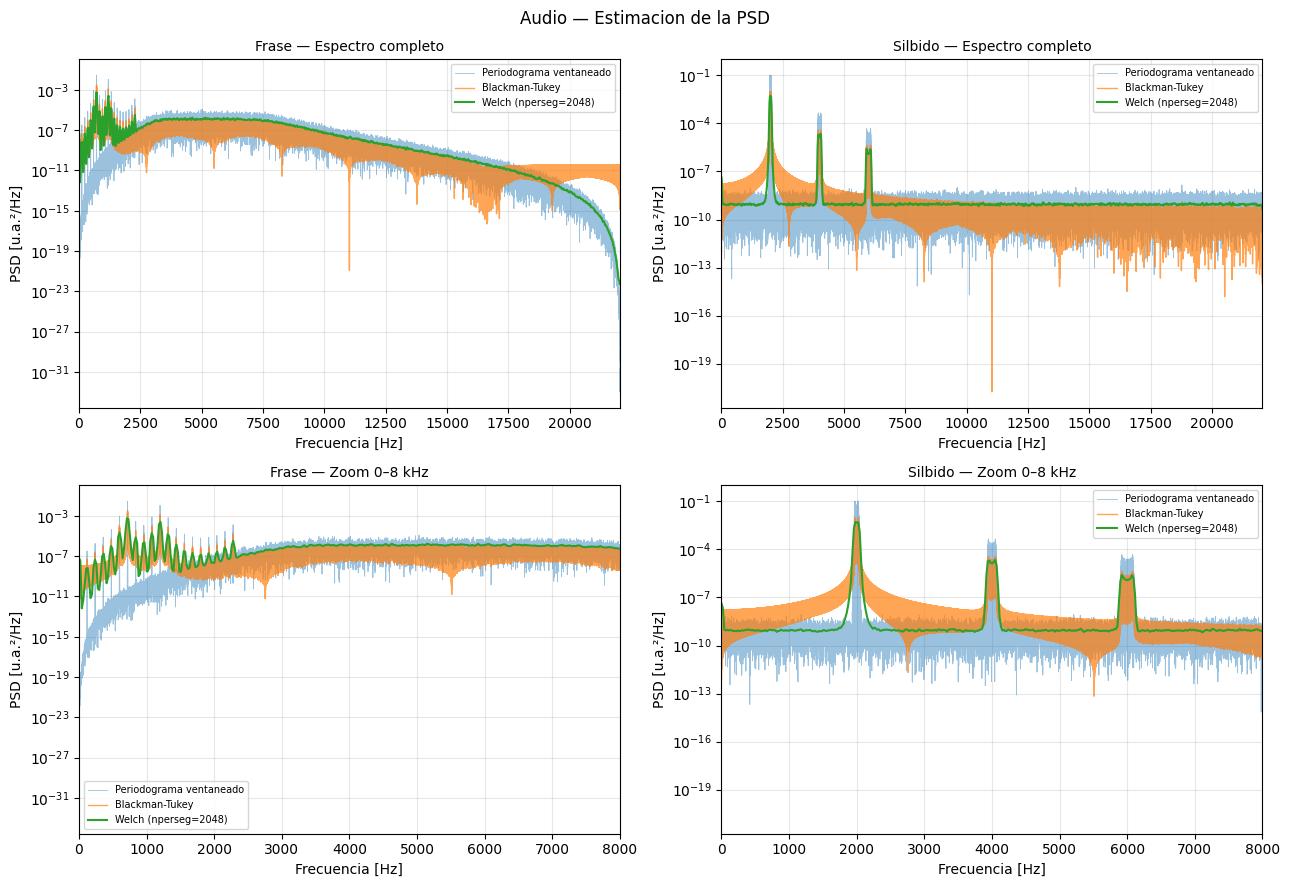

In [24]:
# --- Audio ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Audio — Estimacion de la PSD', fontsize=12)

datos_audio = [
    ('Frase',   f_fra_p, Pxx_fra_p, f_fra_bt, Pxx_fra_bt, f_fra_w, Pxx_fra_w, fs_frase, NPERSEG_FRAS),
    ('Silbido', f_sil_p, Pxx_sil_p, f_sil_bt, Pxx_sil_bt, f_sil_w, Pxx_sil_w, fs_silb,  NPERSEG_SILB),
]

for col, (nombre, fp, Pp, fbt, Pbt, fw, Pw, fs_a, nps) in enumerate(datos_audio):
    for row, (xlim, titulo) in enumerate([(fs_a/2, 'Espectro completo'), (8000, 'Zoom 0–8 kHz')]):
        ax = axes[row][col]
        ax.semilogy(fp,  Pp,  lw=0.6, alpha=0.45, color='C0', label='Periodograma ventaneado')
        ax.semilogy(fbt, Pbt, lw=1.0, alpha=0.7,  color='C1', label='Blackman-Tukey')
        ax.semilogy(fw,  Pw,  lw=1.5, color='C2', label=f'Welch (nperseg={nps})')
        ax.set_xlabel('Frecuencia [Hz]')
        ax.set_ylabel('PSD [u.a.²/Hz]')
        ax.set_title(f'{nombre} — {titulo}', fontsize=10)
        ax.set_xlim(0, min(xlim, fs_a/2))
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observaciones sobre la estimacion

ECG: la mayor parte de la energia se concentra por debajo de 40 Hz. Los complejos QRS, de corta duracion pero gran amplitud, contienen componentes hasta aproximadamente 100 Hz. El periodograma ventaneado muestra alta varianza (fluctuaciones pronunciadas) que el metodo de Welch suaviza significativamente.

PPG: senal de muy baja frecuencia dominada por el ritmo cardiaco (~1 Hz) y sus armonicos. El espectro cae rapidamente por encima de 10 Hz. La frecuencia respiratoria (~0.2–0.3 Hz) puede aparecer como modulacion de amplitud del pico principal.

Frase (voz): el habla ocupa el rango tipico de 100 Hz a 4000 Hz, con los formantes F1–F3 visibles como picos en la envolvente espectral. Por encima de 4 kHz la energia cae en la mayoria de los sonidos vocalicos, aunque las fricativas (s, f, sh) pueden extenderse hasta 8 kHz.

Silbido: al contrario de la voz, el silbido es una senal casi tonal y angosta. El pico de la fundamental es muy estrecho y concentra la mayor parte de la energia. Se esperan pocos armonicos y ancho de banda reducido comparado con la frase.

## Seccion 2 — Estimacion del ancho de banda

Se utiliza el criterio de contenido de potencia: la frecuencia $f_{BW}^{(p)}$ es aquella por debajo de la cual se acumula una fraccion $p$ de la potencia total:

$$f_{BW}^{(p)} = \min\left\{f : \int_0^{f} \hat{S}(f')\,df' \geq p \cdot \int_0^{f_{max}} \hat{S}(f')\,df'\right\}$$

Se reportan tres niveles: $p \in \{0.90,\, 0.95,\, 0.99\}$.

Como metodo de estimacion de la PSD se usa Welch, que produce el estimador con menor varianza entre los tres calculados.

In [25]:
def bw_contenido(f, Pxx, porcentajes=(0.90, 0.95, 0.99)):
    df     = f[1] - f[0]
    P_cum  = np.cumsum(Pxx) * df
    P_tot  = P_cum[-1]
    bws = {}
    for p in porcentajes:
        idx     = np.searchsorted(P_cum, p * P_tot)
        bws[p]  = f[min(idx, len(f) - 1)]
    return bws, P_tot


senales_bw = [
    ('ECG',     f_ecg_w,  Pxx_ecg_w,  fs_ecg),
    ('PPG',     f_ppg_w,  Pxx_ppg_w,  fs_ppg),
    ('Frase',   f_fra_w,  Pxx_fra_w,  fs_frase),
    ('Silbido', f_sil_w,  Pxx_sil_w,  fs_silb),
]

PORCENTAJES = (0.90, 0.95, 0.99)

resultados_bw = {}
for nombre, f, Pxx, fs in senales_bw:
    bws, P_tot = bw_contenido(f, Pxx, PORCENTAJES)
    resultados_bw[nombre] = {'bws': bws, 'P_tot': P_tot, 'fs': fs}

print('Anchos de banda calculados.')

Anchos de banda calculados.


In [26]:
def print_table(headers, rows, title):
    col_w = [max(len(h), max(len(r[i]) for r in rows)) + 2 for i, h in enumerate(headers)]
    sep   = '+' + '+'.join('-' * w for w in col_w) + '+'
    fmt   = '|' + '|'.join(f'{{:^{w}}}' for w in col_w) + '|'
    print(f'\n{title}')
    print(sep)
    print(fmt.format(*headers))
    print(sep)
    for row in rows:
        print(fmt.format(*row))
    print(sep)


headers = ['Senal', 'fs [Hz]', 'P total', 'BW 90% [Hz]', 'BW 95% [Hz]', 'BW 99% [Hz]']
rows = []
for nombre, data in resultados_bw.items():
    rows.append([
        nombre,
        f"{data['fs']}",
        f"{data['P_tot']:.4g}",
        f"{data['bws'][0.90]:.1f}",
        f"{data['bws'][0.95]:.1f}",
        f"{data['bws'][0.99]:.1f}",
    ])

print_table(headers, rows, 'Estimacion del ancho de banda por contenido de potencia (metodo de Welch)')


Estimacion del ancho de banda por contenido de potencia (metodo de Welch)
+---------+---------+---------+-------------+-------------+-------------+
|  Senal  | fs [Hz] | P total | BW 90% [Hz] | BW 95% [Hz] | BW 99% [Hz] |
+---------+---------+---------+-------------+-------------+-------------+
|   ECG   | 1000.0  | 0.02174 |    23.4     |    29.3     |    228.5    |
|   PPG   |  400.0  | 0.7897  |     2.3     |     3.1     |     3.9     |
|  Frase  |  44100  | 0.04317 |   4801.9    |   6438.4    |   8247.2    |
| Silbido |  44100  | 0.3949  |   2024.1    |   2045.7    |   2045.7    |
+---------+---------+---------+-------------+-------------+-------------+


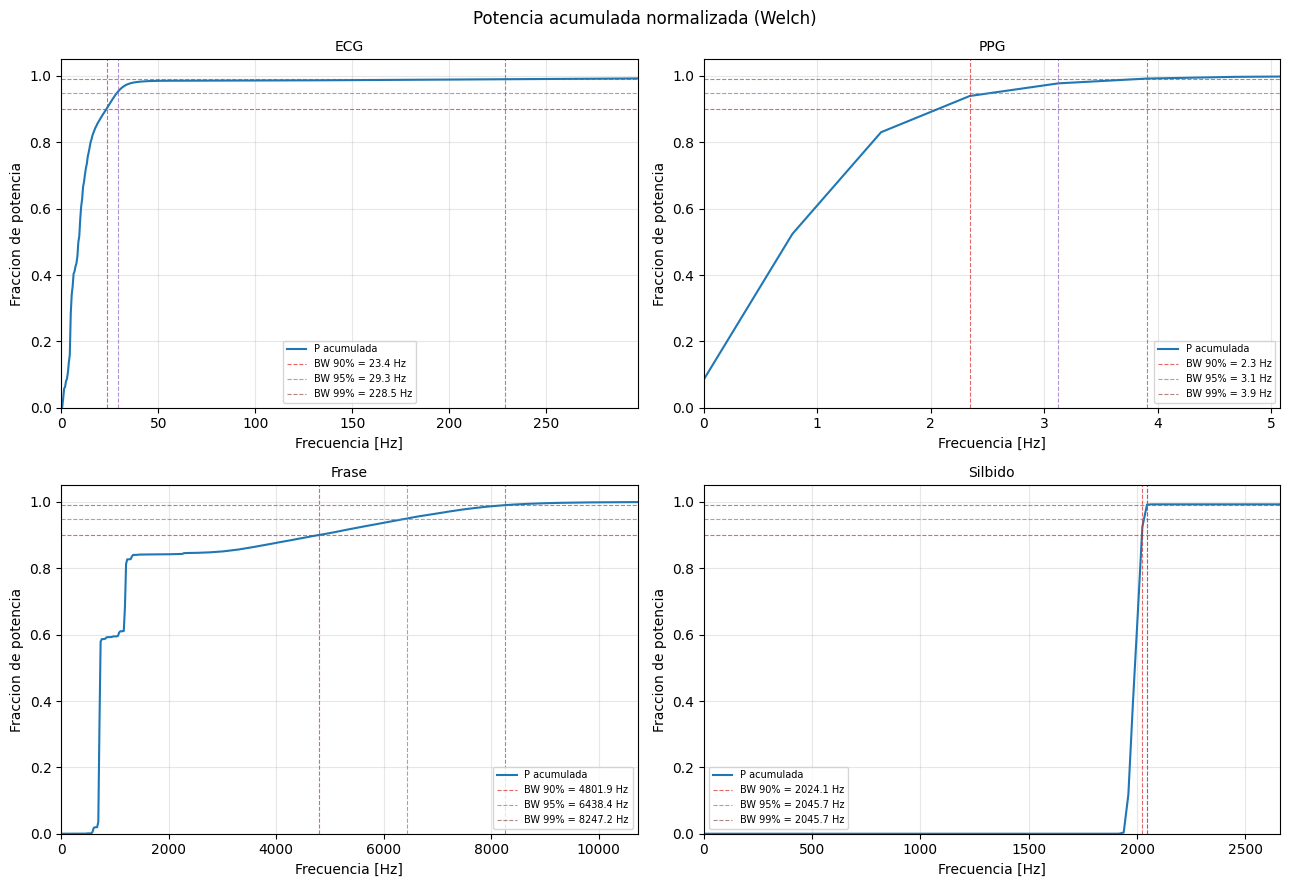

In [27]:
# grafica de la potencia acumulada normalizada para cada senal
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Potencia acumulada normalizada (Welch)', fontsize=12)

colores_bw = {'0.90': 'C3', '0.95': 'C4', '0.99': 'C5'}

for ax, (nombre, f, Pxx, fs) in zip(axes.flat, senales_bw):
    df       = f[1] - f[0]
    P_cum    = np.cumsum(Pxx) * df
    P_cum_n  = P_cum / P_cum[-1]

    ax.plot(f, P_cum_n, lw=1.5, color='C0', label='P acumulada')

    for p, color in zip(PORCENTAJES, ['C3', 'C4', 'C5']):
        f_bw = resultados_bw[nombre]['bws'][p]
        ax.axhline(p,    color=color, lw=0.8, ls='--', alpha=0.7)
        ax.axvline(f_bw, color=color, lw=0.8, ls='--', alpha=0.7, label=f'BW {p*100:.0f}% = {f_bw:.1f} Hz')

    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Fraccion de potencia')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlim(0, resultados_bw[nombre]['bws'][0.99] * 1.3)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analisis de los resultados

ECG: senal de baja frecuencia con la mayor parte de la energia entre 0.5 Hz y ~40 Hz. El criterio del 99% incluye la actividad de alta frecuencia de los complejos QRS y del ruido muscular residual.

PPG: la potencia esta muy concentrada alrededor del fundamental cardiaco (~1 Hz) y sus primeros armonicos. El ancho de banda al 99% es considerablemente menor que el de las otras senales; el PPG es la senal con espectro mas angosto de las analizadas.

Frase: la voz es la senal con mayor ancho de banda. La informacion articulatoria relevante ocupa desde ~100 Hz hasta varios kHz. El criterio del 90% ya puede estar cerca de los 3–4 kHz (banda telefonica), mientras que al 99% se incluyen las fricativas de alta frecuencia.

Silbido: a pesar de tener la misma frecuencia de muestreo que la frase, el silbido es una senal casi monocromatica. La mayor parte de la potencia esta concentrada en una banda angosta alrededor de la frecuencia de silbido (~1–3 kHz), lo que produce un ancho de banda efectivo mucho menor que el de la voz.

## Bonus — Senal de electroencefalograma (EEG) sintetico

El EEG registra la actividad electrica del cerebro mediante electrodos colocados en el cuero cabelludo. Las senales de EEG son de muy baja amplitud (~10–100 uV) y presentan ritmos caracteristicos que se estudian en distintas bandas de frecuencia:

| Banda | Rango | Descripcion |
|:--|:--|:--|
| Delta | 0.5–4 Hz | Sueno profundo |
| Theta | 4–8 Hz | Somnolencia, meditacion |
| Alfa | 8–13 Hz | Relajacion despierto, ojos cerrados |
| Beta | 13–30 Hz | Estado de alerta, concentracion |
| Gamma | 30–100 Hz | Procesamiento cognitivo de alto nivel |

Como no se dispone de un registro real en este repositorio, se genera una senal sintetica que replica la estructura espectral tipica de un EEG en estado de relajacion (predominio de alfa). Cada banda se modela como ruido coloreado filtrado en esa banda, con amplitudes relativas representativas.

La digitalizacion tipica de EEG usa amplificadores diferenciales con rango de entrada de $\pm$100 uV y ADC de 16–24 bits a tasas de muestreo de 250–2048 Hz. Aqui se simula $f_s = 256$ Hz, que es una tasa estandar en sistemas clinicos de baja gama.

EEG sintetico: N=30720, fs=256.0 Hz, duracion=120 s
Amplitud RMS = 50.00 uV,  pico = 210.55 uV


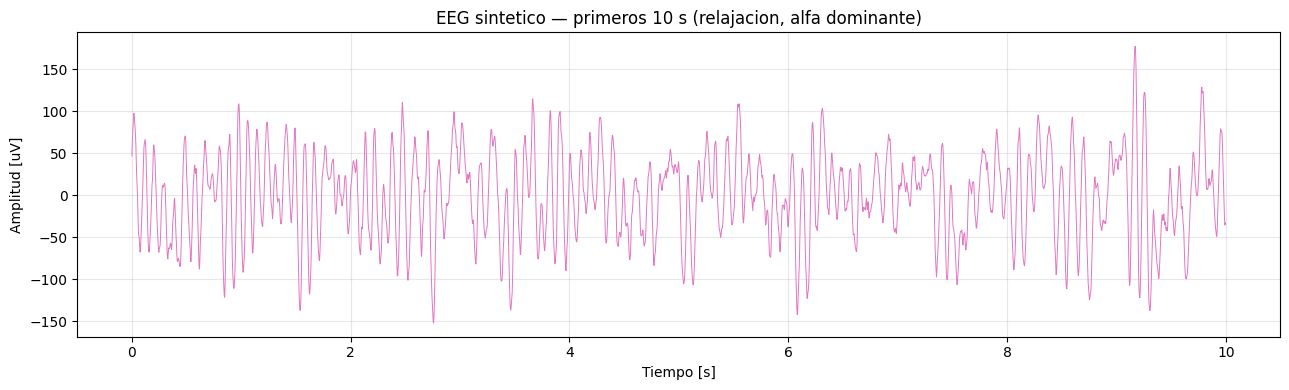

In [28]:
rng      = np.random.default_rng(seed=42)
fs_eeg   = 256.0
T_eeg    = 120.0        # 2 minutos de registro
N_eeg    = int(T_eeg * fs_eeg)
t_eeg    = np.arange(N_eeg) / fs_eeg

# amplitudes relativas por banda (relajacion: alfa dominante)
bandas = {
    'delta':  (0.5, 4.0,  3.0),
    'theta':  (4.0, 8.0,  1.5),
    'alfa':   (8.0, 13.0, 5.0),   # banda dominante
    'beta':   (13.0, 30.0, 1.0),
    'gamma':  (30.0, 80.0, 0.3),
}

eeg = np.zeros(N_eeg)
for nombre_b, (f_lo, f_hi, amp) in bandas.items():
    ruido = rng.standard_normal(N_eeg)
    b, a  = sig.butter(4, [f_lo / (fs_eeg/2), f_hi / (fs_eeg/2)], btype='bandpass')
    comp  = sig.filtfilt(b, a, ruido)
    comp  = comp / np.std(comp) * amp   # normalizar y escalar
    eeg  += comp

# escalar a amplitud tipica de EEG: ~50 uV RMS
eeg = eeg / np.std(eeg) * 50.0   # unidades: uV

print(f'EEG sintetico: N={N_eeg}, fs={fs_eeg} Hz, duracion={T_eeg:.0f} s')
print(f'Amplitud RMS = {np.std(eeg):.2f} uV,  pico = {np.max(np.abs(eeg)):.2f} uV')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_eeg[:int(10*fs_eeg)], eeg[:int(10*fs_eeg)], lw=0.7, color='C6')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud [uV]')
ax.set_title('EEG sintetico — primeros 10 s (relajacion, alfa dominante)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

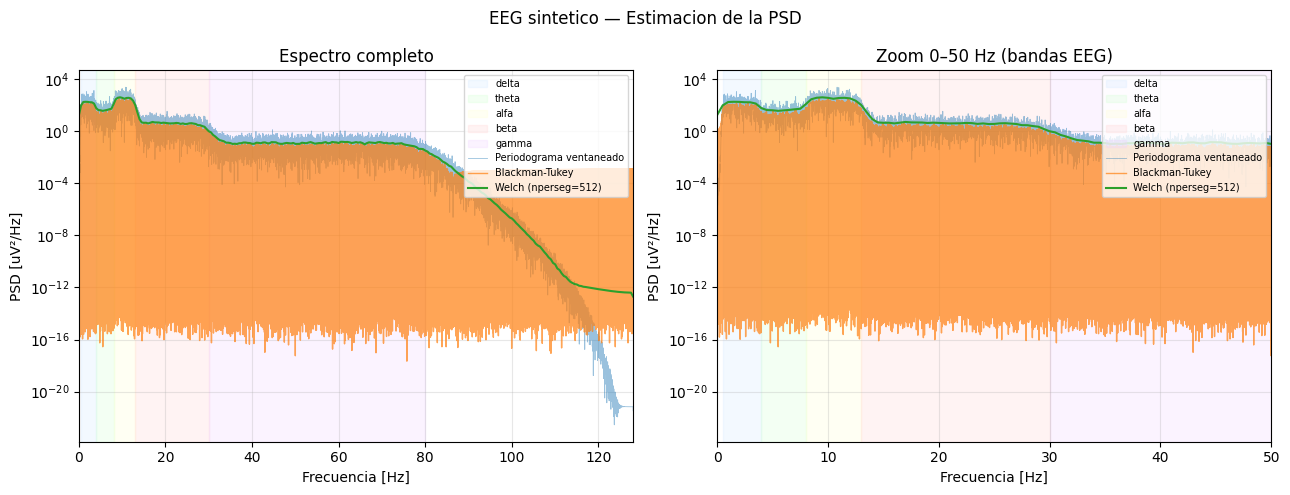

In [29]:
# PSD del EEG sintetico
nperseg_eeg  = 512
f_eeg_w,  Pxx_eeg_w  = sig.welch(eeg, fs=fs_eeg, window='hann', nperseg=nperseg_eeg, noverlap=nperseg_eeg//2, scaling='density')
f_eeg_p,  Pxx_eeg_p  = sig.periodogram(eeg, fs=fs_eeg, window='hann', scaling='density')
f_eeg_bt, Pxx_eeg_bt = blackman_tukey(eeg, fs_eeg, M=N_eeg//8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EEG sintetico — Estimacion de la PSD', fontsize=12)

# bandas sombreadas
colores_b  = {'delta': '#d0e8ff', 'theta': '#d0ffd0', 'alfa': '#ffffd0', 'beta': '#ffd0d0', 'gamma': '#f0d0ff'}

for ax in axes:
    for nombre_b, (f_lo, f_hi, _) in bandas.items():
        ax.axvspan(f_lo, f_hi, alpha=0.25, color=colores_b[nombre_b], label=nombre_b)
    ax.semilogy(f_eeg_p,  Pxx_eeg_p,  lw=0.6, alpha=0.45, color='C0', label='Periodograma ventaneado')
    ax.semilogy(f_eeg_bt, Pxx_eeg_bt, lw=1.0, alpha=0.7,  color='C1', label='Blackman-Tukey')
    ax.semilogy(f_eeg_w,  Pxx_eeg_w,  lw=1.5, color='C2', label=f'Welch (nperseg={nperseg_eeg})')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD [uV²/Hz]')
    ax.grid(True, alpha=0.3)

axes[0].set_xlim(0, fs_eeg/2)
axes[0].set_title('Espectro completo')
axes[0].legend(fontsize=7, loc='upper right')

axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom 0–50 Hz (bandas EEG)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [30]:
# potencia por banda y ancho de banda del EEG
bws_eeg, P_tot_eeg = bw_contenido(f_eeg_w, Pxx_eeg_w, PORCENTAJES)

headers_eeg = ['Banda', 'Rango [Hz]', 'Potencia [uV2]', '% del total']
rows_eeg = []
for nombre_b, (f_lo, f_hi, _) in bandas.items():
    mask = (f_eeg_w >= f_lo) & (f_eeg_w <= f_hi)
    P_b  = np.trapezoid(Pxx_eeg_w[mask], f_eeg_w[mask])
    rows_eeg.append([nombre_b, f'{f_lo:.1f}-{f_hi:.1f}', f'{P_b:.2f}', f'{100*P_b/P_tot_eeg:.1f}%'])

print_table(headers_eeg, rows_eeg, 'EEG sintetico - potencia por banda')

# agregar al resumen general
resultados_bw['EEG'] = {'bws': bws_eeg, 'P_tot': P_tot_eeg, 'fs': fs_eeg}

headers = ['Senal', 'fs [Hz]', 'BW 90% [Hz]', 'BW 95% [Hz]', 'BW 99% [Hz]']
rows_all = []
for nombre in ['ECG', 'PPG', 'Frase', 'Silbido', 'EEG']:
    data = resultados_bw[nombre]
    rows_all.append([
        nombre,
        f"{data['fs']:.0f}",
        f"{data['bws'][0.90]:.1f}",
        f"{data['bws'][0.95]:.1f}",
        f"{data['bws'][0.99]:.1f}",
    ])

print_table(headers, rows_all, 'Resumen: ancho de banda por contenido de potencia (todas las senales)')


EEG sintetico - potencia por banda
+-------+------------+----------------+-------------+
| Banda | Rango [Hz] | Potencia [uV2] | % del total |
+-------+------------+----------------+-------------+
| delta |  0.5-4.0   |     556.29     |    22.1%    |
| theta |  4.0-8.0   |     201.35     |    8.0%     |
| alfa  |  8.0-13.0  |    1610.62     |    64.0%    |
| beta  | 13.0-30.0  |     109.06     |    4.3%     |
| gamma | 30.0-80.0  |      7.23      |    0.3%     |
+-------+------------+----------------+-------------+

Resumen: ancho de banda por contenido de potencia (todas las senales)
+---------+---------+-------------+-------------+-------------+
|  Senal  | fs [Hz] | BW 90% [Hz] | BW 95% [Hz] | BW 99% [Hz] |
+---------+---------+-------------+-------------+-------------+
|   ECG   |  1000   |    23.4     |    29.3     |    228.5    |
|   PPG   |   400   |     2.3     |     3.1     |     3.9     |
|  Frase  |  44100  |   4801.9    |   6438.4    |   8247.2    |
| Silbido |  44100  |  

### Analisis del EEG

El espectro del EEG sintetico muestra claramente el pico en la banda alfa (8–13 Hz), que es la banda dominante en el estado de relajacion modelado. Esto coincide con observaciones clinicas: cuando un sujeto cierra los ojos y se relaja, el ritmo alfa se hace prominente en regiones occipitales y parietales.

El ancho de banda al 99% es el mas bajo de todas las senales analizadas junto con el PPG, porque la potencia esta muy concentrada en la region de bajas frecuencias (< 30 Hz). Esto contrasta con la voz y el silbido, cuya energia se extiende hasta varios kHz.

### Resumen general

Las senales biomedicas lentas (PPG, EEG) concentran su energia en las bandas de baja frecuencia y requieren tasas de muestreo moderadas (256–400 Hz). El ECG, aunque tambien es de baja frecuencia en su componente principal, necesita preservar la morfologia de pico del complejo QRS, lo cual demanda un margen mayor (hasta ~100 Hz). Las senales de audio tienen el mayor ancho de banda, con la voz extendiendose hasta varios kHz y el silbido siendo la excepcion: a pesar de su alta frecuencia de muestreo, ocupa una banda muy angosta alrededor de su fundamental.